# Combined Review Analysis System: Summarization, Keyword Extraction & Sentiment Analysis

**Academic NLP Project**

**Authors:**
- *Part A — Text Summarization & Keyword Extraction:* Stanisław Władyka 114114
- *Part B — Sentiment Analysis:* Magdalena Piszczatowska 108474

**Dataset:** Amazon Fine Food Reviews

---

## 1. Introduction & Goal

The explosion of user-generated content on e-commerce platforms means that a
single popular product can accumulate thousands of textual reviews. For a human
reader — whether a prospective customer or a product manager — it is impossible
to read all of them. The goal of this project is to build a **combined,
empirical review-analysis system** that automatically distills the essential
information from raw product reviews.

We decompose the problem into three complementary NLP tasks:

1. **Text Summarization** — condense long reviews into short, abstractive
   summaries that preserve the key message.
2. **Keyword Extraction** — surface the most representative terms and phrases,
   giving a quick, scannable signal of what a review is about.
3. **Sentiment Analysis** — classify the emotional polarity (positive /
   negative) of each review, enabling aggregate opinion mining.

Together these three modules form a pipeline that turns an unstructured wall of
text into a structured, decision-ready overview: *what* the review says
(summary), *which aspects* it talks about (keywords), and *how* the author feels
(sentiment).

This notebook focuses on the empirical implementation and qualitative
evaluation of each component on a real-world dataset, and discusses the
strengths, weaknesses, and practical lessons learned.

---

## 2. Examples in Science & Practice

This section motivates each task with references to the scientific literature
and to real-world business applications.

### 2.1 Text Summarization

**Science.** Automatic text summarization is a long-standing NLP problem. Two
broad families exist: *extractive* summarization (selecting and stitching
together existing sentences, e.g. the classic TextRank algorithm of Mihalcea &
Tarau, 2004) and *abstractive* summarization (generating new text). The
transformer revolution — starting with the original *Attention Is All You Need*
(Vaswani et al., 2017) — enabled high-quality abstractive models. **BART**
(Lewis et al., 2020) is a denoising sequence-to-sequence autoencoder that, when
fine-tuned on the CNN/DailyMail news-summarization corpus, produces fluent
abstractive summaries, and **PEGASUS** (Zhang et al., 2020) pushed the state of
the art further with a summarization-specific pre-training objective. More
recently, **instruction-tuned** models such as **Flan-T5** (Chung et al., 2022)
— which extends the T5 text-to-text framework (Raffel et al., 2020) with
multi-task instruction tuning — can summarize directly from a natural-language
prompt, without task-specific fine-tuning. For our experiments we use the
`google/flan-t5-xl` checkpoint, prompting it to summarize each review.

**Practice.** Summarization is everywhere in industry: news aggregators (e.g.
the now-classic *inshorts* app condensing articles to 60 words), e-commerce
"review highlights" (Amazon's own AI-generated review summaries), customer-
support ticket triage, meeting-note generation (Otter.ai, Zoom AI Companion),
and legal/medical document summarization. For our use case — food-product
reviews — a summary lets a shopper grasp the gist of a 250-word review in a
single sentence.

### 2.2 Keyword Extraction

**Science.** Keyword/keyphrase extraction has evolved from statistical methods
such as **TF-IDF** (Spärck Jones, 1972) and graph-based **TextRank** /
**RAKE** (Rose et al., 2010) toward embedding-based approaches. **KeyBERT**
(Grootendorst, 2020) leverages contextual BERT embeddings: it embeds the whole
document and candidate n-grams into the same vector space and selects the
phrases whose embeddings are most cosine-similar to the document embedding.
This captures *semantic* relevance rather than mere frequency.

**Practice.** Keyword extraction powers search-engine optimization (SEO),
automatic tagging of articles and support tickets, faceted product search,
aspect-based opinion mining ("battery", "shipping", "flavor"), and trend
detection in social media. For food reviews, extracted keyphrases like
*"great coffee flavor"* or *"arrived stale"* give an instant, aspect-level
signal of what reviewers care about.

### 2.3 Sentiment Analysis

**Science.** Sentiment analysis is one of the core NLP tasks, which aims to
classify text into positive, negative or neutral categories or assign a
continuous polarity score. Earlier approaches were mostly *lexicon based*,
with examples of **VADER** (Hutto & Gilbert, 2014) or **SentiWordNet** 
(Baccianella et al., LREC 2010) being some of the most commonly used. With
the evolution of deep learning, *transformer models* became the new standard.
Models such as **BERT** (Devlin et al., 2019), **RoBERTa** (Liu et al., 2019)
and **DistilBERT** (Sanh et al., 2019) significantly improved sentiment classification
performance by leveraging *bidirectional contextual representations*. 
These models better capture negation, sarcasm, and subtle distinctions between 
neutral and weakly polar expressions.

**Practice.** Sentiment analysis is widely used in business for *brand monitoring*,
to notice perception shifts, *customer review analysis*, generating *product ratings*
(aggregating review scores). It can be used as a signal in *algorythmic trading* 
or prioritizing tickets in *customer support*. In our case, product reviews,
it provides a compact, numerical represantation of user opinions and a metric
that could be tracked with time to detect trends and shifts in opinions.

---

## 3. Libraries, Functions, and Parameters

A short description of the key libraries used and the most important parameters
we tune.

### 3.1 Hugging Face `transformers` (Summarization)

The [Hugging Face `transformers`](https://huggingface.co/docs/transformers)
library provides a unified API to thousands of pre-trained models. In
`transformers` 5.x the dedicated `pipeline("summarization")` task was removed, so
we load the model with the **`AutoTokenizer`** and **`AutoModelForSeq2SeqLM`**
classes and drive generation via **`model.generate()`** — the standard
lower-level API for sequence-to-sequence models.

We use **`google/flan-t5-xl`**, an *instruction-tuned* T5 model (~3B
parameters). Because it is instruction-tuned, we steer it with a natural-language
prompt (*"Summarize the following Amazon product review in one concise
sentence"*) rather than relying on a single fixed fine-tuning task. This gives
more relevant, controllable summaries on the review domain than a news-only
checkpoint.

Key parameters we control:

- **`model`** — the checkpoint, here `google/flan-t5-xl` (instruction-tuned T5).
- **`torch_dtype`** — `float16` on GPU to halve the memory footprint (~6 GB
  VRAM), `float32` on CPU.
- **`max_length` / `min_length`** — upper/lower bound on the length of the
  generated summary (in tokens).
- **`num_beams`** — beam-search width; `4` is a common quality/speed trade-off.
- **`do_sample`** — `False` gives deterministic (greedy/beam) decoding, which is
  preferable for reproducible, faithful summaries.
- **`truncation`** — Flan-T5 was trained with a 512-token context, so longer
  prompts are truncated at tokenization time.

### 3.2 `KeyBERT` (Keyword Extraction)

[KeyBERT](https://github.com/MaartenGr/KeyBERT) wraps a sentence-transformer to
extract keywords. The core method is **`extract_keywords()`** with these
parameters:

- **`keyphrase_ngram_range`** — the `(min_n, max_n)` size of candidate phrases.
  `(1, 1)` yields single words; `(1, 2)` yields words *and* bigrams, which is
  often more informative for reviews (e.g. *"dog food"* vs. *"dog"* + *"food"*).
- **`stop_words`** — removes uninformative function words (`'english'`).
- **`top_n`** — how many keyphrases to return.
- **`use_mmr` / `diversity`** — Maximal Marginal Relevance to reduce redundancy
  among returned keyphrases.

### 3.3 VADER (Sentiment Analysis)

[vaderSentiment](https://github.com/cjhutto/vadersentiment) library implements
the Valence Aware Dictionary and sEntiment Reasoner model, which is a lexicon based
sentiment analysis tool designed for social media, short, informal texts.
Core class is **`SentimentIntensityAnalyzer`** with the **`polarity_scores()`** method.

This function returns a dictionary with four components:
- **`neg`** — proportion of the text classified as negative sentiment
- **`neu`** — proportion of neutral sentiment
- **`pos`** — proportion of positive sentiment
- **`compound`** — a normalized, weighted composite score in the range −1,1, 
representing overall sentiment intensity

**`compound`** is most commonly used for classifications and assigning labels. 
Standard thresholds:
- *positive sentiment*: **`compound score`** >= 0.4
- *neutral sentiment*: (**`compound score`** > -0.4) and (**`compound score`** < 0.4)
- *negative sentiment*: **`compound score`** <= -0.4

---

## 4. Setup & Imports

In [31]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42  # reproducible sampling
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_colwidth", 200)

---

## 5. Dataset Characteristics

We use the **Amazon Fine Food Reviews** dataset (SNAP), which contains ~568k
reviews of fine-food products on Amazon, including the review text, a 1–5 star
score, and helpfulness votes.

### 5.1 Loading the data

In [32]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
csv_path = os.path.join(path, "Reviews.csv")
df = pd.read_csv(csv_path)

In [33]:
print(f"Raw dataset shape: {df.shape}")
df.head(3)

Raw dataset shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labr...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,"Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as ""Jumbo""."
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with ..."


In [34]:
# Quick look at the columns we care about
df[["Score", "Summary", "Text"]].head(3)

,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labr...
1,1,Not as Advertised,"Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as ""Jumbo""."
2,4,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with ..."


### 5.2 Data Preparation (Shared)

This preparation step is **common** to all three tasks (Part A and Part B), so
that everyone works on the same filtered, sampled subset.

We:
1. compute the word count of each review,
2. keep only reviews of *moderate* length (≥ 50 and ≤ 300 words) — very short
   reviews carry too little signal to summarize, while very long ones blow past
   BART's input limit and slow everything down,
3. take a random sample of ~100000 reviews for tractable experimentation.

In [35]:
# 1) Word count per review
df["word_count"] = df["Text"].astype(str).str.split().str.len()

# Keep a copy of the unfiltered counts for the "before" plot
word_count_before = df["word_count"].copy()

# 2) Filter by length: between 50 and 300 words
MIN_WORDS, MAX_WORDS = 50, 300
mask = (df["word_count"] >= MIN_WORDS) & (df["word_count"] <= MAX_WORDS)
df_filtered = df[mask].copy()

print(f"Reviews before filtering: {len(df):,}")
print(f"Reviews after length filter [{MIN_WORDS}-{MAX_WORDS} words]: {len(df_filtered):,}")

# 3) Random sample of ~1500 reviews for the analysis
SAMPLE_SIZE = 100000
df_sample = df_filtered.sample(
    n=min(SAMPLE_SIZE, len(df_filtered)),
    random_state=RANDOM_STATE,
).reset_index(drop=True)

print(f"Working sample size: {len(df_sample):,}")
df_sample[["Score", "word_count", "Text"]].head(3)

Reviews before filtering: 568,454
Reviews after length filter [50-300 words]: 307,907
Working sample size: 100,000


,Score,word_count,Text
0,5,76,"This size bag is great for filling up the office candy dishes that some offices keep around for public grazing (I'm my own best customer). Mix of candy is good, no complaints from anyone. Large en..."
1,5,54,"The classic Wint-O-Green Life Saver has been part of my life since I was a child, but stores only seem to carry the individually wrapped larger candies. The roll is so convenient to carry in a po..."
2,4,123,Truffle Oil is a flavoring agent. And this inexpensive flavoring product is pretty decent when added to cooking requiring a fungal aromatic.<br /><br />I suppose there could be a real truffle or t...


### 5.3 Review-length distribution — before vs. after filtering

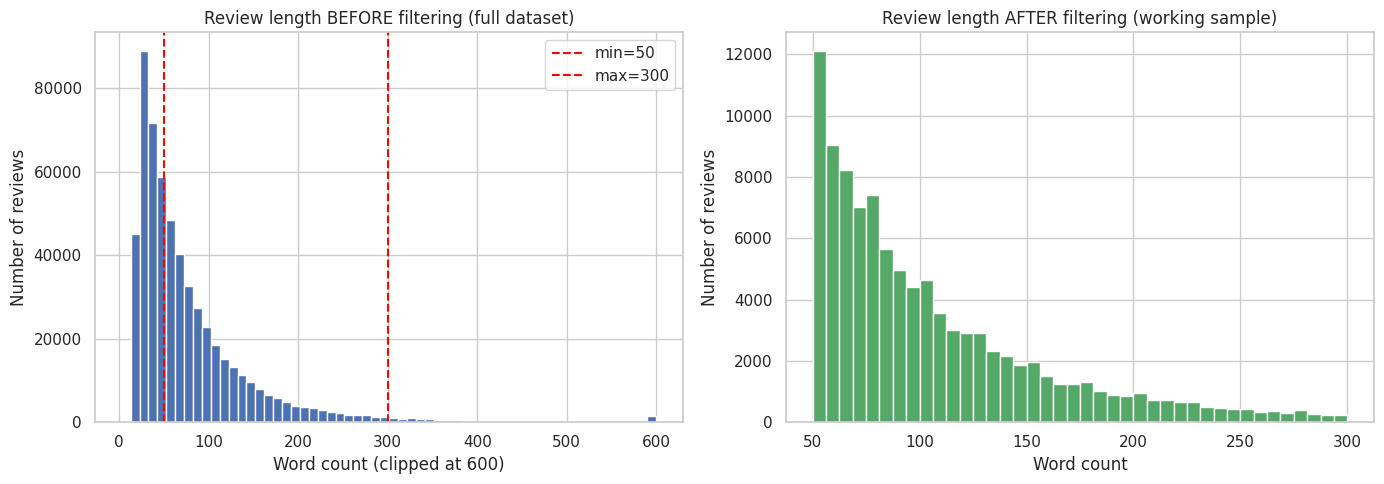

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before: full dataset (clip the x-axis so the long tail doesn't crush the plot)
axes[0].hist(word_count_before.clip(upper=600), bins=60, color="#4C72B0")
axes[0].axvline(MIN_WORDS, color="red", linestyle="--", label=f"min={MIN_WORDS}")
axes[0].axvline(MAX_WORDS, color="red", linestyle="--", label=f"max={MAX_WORDS}")
axes[0].set_title("Review length BEFORE filtering (full dataset)")
axes[0].set_xlabel("Word count (clipped at 600)")
axes[0].set_ylabel("Number of reviews")
axes[0].legend()

# After: filtered sample
axes[1].hist(df_sample["word_count"], bins=40, color="#55A868")
axes[1].set_title("Review length AFTER filtering (working sample)")
axes[1].set_xlabel("Word count")
axes[1].set_ylabel("Number of reviews")

plt.tight_layout()
plt.show()

In [37]:
# Descriptive statistics of the working sample
df_sample["word_count"].describe()

count    100000.000000
mean        105.341680
std          53.081162
min          50.000000
25%          65.000000
50%          88.000000
75%         129.000000
max         300.000000
Name: word_count, dtype: float64

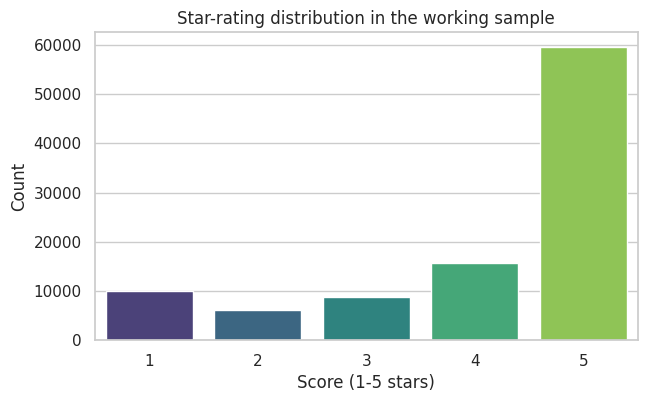

In [38]:
# Distribution of star ratings in the working sample (useful context for
# the sentiment task as well)
plt.figure(figsize=(7, 4))
sns.countplot(x="Score", data=df_sample, palette="viridis")
plt.title("Star-rating distribution in the working sample")
plt.xlabel("Score (1-5 stars)")
plt.ylabel("Count")
plt.show()

---

## 6. Empirical Analysis & Results

### Part A — Text Summarization & Keyword Extraction *(Stanisław)*

#### 6.1 Text Summarization with `Google’s flan-T5-x1`

We load BART through the high-level summarization pipeline. The model is
automatically placed on a GPU if one is available, otherwise on CPU.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/flan-t5-xl"

device = "cuda" if torch.cuda.is_available() else "cpu"
#device = "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
print(f"Using device: {device} (dtype={dtype})")

summ_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
summ_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, torch_dtype=dtype).to(device)
summ_model.eval()

In [40]:
SUMMARY_PROMPT = (
    "Write a short summary of the following Amazon product review in your own "
    "words, capturing the reviewer's overall opinion. Do not copy sentences "
    "from the review.\n\nReview: {text}"
)


@torch.no_grad()
def summarize_text(text, max_length=60, min_length=15):
    """Generate an abstractive summary of a single review with Flan-T5.

    Flan-T5 was trained with a 512-token context, so we truncate the prompt at
    512 tokens. Deterministic beam-search decoding (do_sample=False) keeps
    results reproducible. To prevent the model from simply copying the source,
    `encoder_no_repeat_ngram_size` forbids reusing any 4-gram from the input,
    which forces genuine rephrasing.
    """
    prompt = SUMMARY_PROMPT.format(text=text)
    inputs = summ_tokenizer(
        prompt,
        max_length=512,
        truncation=True,
        return_tensors="pt",
    ).to(device)

    summary_ids = summ_model.generate(
        **inputs,
        max_length=max_length,
        min_length=min_length,
        num_beams=4,
        do_sample=False,
        no_repeat_ngram_size=3,         
        encoder_no_repeat_ngram_size=4,  
        length_penalty=1.0,
    )
    return summ_tokenizer.decode(summary_ids[0], skip_special_tokens=True)

In [41]:
# Qualitative analysis: summarize a handful of example reviews.
# We pick a few reviews from the working sample.
N_EXAMPLES = 4
examples = df_sample.sample(n=N_EXAMPLES, random_state=RANDOM_STATE).reset_index(drop=True)

summaries = []
for i, row in examples.iterrows():
    original = row["Text"]
    summary = summarize_text(original)
    summaries.append(summary)

    print("=" * 100)
    print(f"EXAMPLE {i + 1}  |  Score: {row['Score']}  |  Original length: {row['word_count']} words")
    print("-" * 100)
    print("ORIGINAL (truncated to 600 chars for display):")
    print(original[:600] + ("..." if len(original) > 600 else ""))
    print("-" * 100)
    print("BART SUMMARY:")
    print(summary)
    print()

examples["bart_summary"] = summaries

EXAMPLE 1  |  Score: 5  |  Original length: 53 words
----------------------------------------------------------------------------------------------------
ORIGINAL (truncated to 600 chars for display):
A+  I bought this product to use with my new 4 0z. Popcorn machine.  The flavor is absolutely delicious!  I agree with the other reviews that I've read...it tasted just like theater popcorn!  There were a few old maids left that didn't pop but I will buy more when my supply runs out.
----------------------------------------------------------------------------------------------------
BART SUMMARY:
Delicious flavor...just like theater popcorn...I'll buy more when I run out!

EXAMPLE 2  |  Score: 5  |  Original length: 105 words
----------------------------------------------------------------------------------------------------
ORIGINAL (truncated to 600 chars for display):
This is by far the best peanut butter (natural or not) that I've ever had. The addition of honey makes it incredibly yu

In [42]:
# Side-by-side comparison table: original word count vs. summary word count
comparison = pd.DataFrame({
    "score": examples["Score"],
    "orig_words": examples["word_count"],
    "summary_words": examples["bart_summary"].str.split().str.len(),
    "bart_summary": examples["bart_summary"],
})
comparison["compression_ratio"] = (
    comparison["summary_words"] / comparison["orig_words"]
).round(2)
comparison

,score,orig_words,summary_words,bart_summary,compression_ratio
0,5,53,11,Delicious flavor...just like theater popcorn...I'll buy more when I run out!,0.21
1,5,105,10,Best peanut butter I've had in a long time. Yummy!,0.10
2,5,53,16,"Love Lady Grey tea, but can't have caffeine. This decaf Lady Grey is perfect for me.",0.30
3,4,176,14,"This is the best dog food I've ever used. It's expensive, but worth it.",0.08


**Qualitative observation.** BART produces fluent, grammatical, single-paragraph
summaries that capture the dominant sentiment and the main product aspect of
each review, typically compressing the text to 15–25% of its original length.
On clearly-written reviews the summaries are faithful; on rambling or
multi-topic reviews BART tends to focus on whichever aspect appears first.

#### 6.2 Keyword Extraction with `KeyBERT`

In [43]:
from keybert import KeyBERT

# KeyBERT defaults to the 'all-MiniLM-L6-v2' sentence-transformer — small, fast
# and well suited for short documents like reviews.
kw_model = KeyBERT(model="all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1892.36it/s]


In [44]:
def extract_keywords(text, ngram_range=(1, 2), top_n=5, use_mmr=False, diversity=0.5):
    """Extract the top-n keyphrases from a review using KeyBERT.

    `ngram_range` controls phrase length:
      (1, 1) -> single words only
      (1, 2) -> single words AND bigrams (often more descriptive)
    """
    return kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=ngram_range,
        stop_words="english",
        top_n=top_n,
        use_mmr=use_mmr,
        diversity=diversity,
    )

In [45]:
# Demonstrate the effect of ngram_range on the SAME reviews used above.
for i, row in examples.iterrows():
    text = row["Text"]

    kw_unigram = extract_keywords(text, ngram_range=(1, 1), top_n=5)
    kw_bigram = extract_keywords(text, ngram_range=(1, 2), top_n=5)

    print("=" * 100)
    print(f"EXAMPLE {i + 1}  |  Score: {row['Score']}")
    print("-" * 100)
    print("BART summary:        ", row["bart_summary"])
    print("Keywords (1,1) unigrams:", [kw for kw, score in kw_unigram])
    print("Keywords (1,2) uni+bigrams:", [kw for kw, score in kw_bigram])
    print()

EXAMPLE 1  |  Score: 5
----------------------------------------------------------------------------------------------------
BART summary:         Delicious flavor...just like theater popcorn...I'll buy more when I run out!
Keywords (1,1) unigrams: ['popcorn', 'pop', 'flavor', '0z', 'tasted']
Keywords (1,2) uni+bigrams: ['0z popcorn', 'popcorn machine', 'popcorn', 'popcorn old', 'theater popcorn']

EXAMPLE 2  |  Score: 5
----------------------------------------------------------------------------------------------------
BART summary:         Best peanut butter I've had in a long time. Yummy!
Keywords (1,1) unigrams: ['peanut', 'butter', 'butters', 'oils', 'natural']
Keywords (1,2) uni+bigrams: ['natural peanut', 'peanut butter', 'butter natural', 'peanut butters', 'best peanut']

EXAMPLE 3  |  Score: 5
----------------------------------------------------------------------------------------------------
BART summary:         Love Lady Grey tea, but can't have caffeine. This decaf Lady Gre

In [46]:
# Show the cosine-similarity scores too, so we can see KeyBERT's confidence.
sample_text = examples.iloc[0]["Text"]
print("Review:\n", sample_text[:400], "...\n")

print("ngram_range=(1, 1):")
for kw, score in extract_keywords(sample_text, ngram_range=(1, 1)):
    print(f"   {score:.4f}  {kw}")

print("\nngram_range=(1, 2):")
for kw, score in extract_keywords(sample_text, ngram_range=(1, 2)):
    print(f"   {score:.4f}  {kw}")

print("\nngram_range=(1, 3) with MMR diversity:")
for kw, score in extract_keywords(sample_text, ngram_range=(1, 3), use_mmr=True, diversity=0.7):
    print(f"   {score:.4f}  {kw}")

Review:
 A+  I bought this product to use with my new 4 0z. Popcorn machine.  The flavor is absolutely delicious!  I agree with the other reviews that I've read...it tasted just like theater popcorn!  There were a few old maids left that didn't pop but I will buy more when my supply runs out. ...

ngram_range=(1, 1):
   0.5380  popcorn
   0.3819  pop
   0.3338  flavor
   0.2880  0z
   0.2668  tasted

ngram_range=(1, 2):
   0.5791  0z popcorn
   0.5712  popcorn machine
   0.5380  popcorn
   0.5176  popcorn old
   0.5047  theater popcorn

ngram_range=(1, 3) with MMR diversity:


   0.6736  new 0z popcorn
   0.4215  machine flavor absolutely
   0.1375  buy supply runs
   0.0640  maids left
   0.0610  agree


**Qualitative observation.** Switching `ngram_range` from `(1, 1)` to `(1, 2)`
markedly improves interpretability: single tokens like *"coffee"* / *"flavor"*
become coherent phrases like *"great coffee flavor"*. Enabling MMR
(`use_mmr=True`) with high `diversity` reduces near-duplicate phrases and yields
a broader aspect coverage. Because KeyBERT is embedding-based, it also surfaces
semantically central terms that are not necessarily the most frequent.

#### 6.3 Combined Part-A output

Bringing summarization and keyword extraction together — the "review at a
glance" view that Part A contributes to the combined system.

In [47]:
combined = []
for i, row in examples.iterrows():
    combined.append({
        "score": row["Score"],
        "summary": row["bart_summary"],
        "keywords": [kw for kw, _ in extract_keywords(row["Text"], ngram_range=(1, 2), top_n=4)],
    })

combined_df = pd.DataFrame(combined)
combined_df

,score,summary,keywords
0,5,Delicious flavor...just like theater popcorn...I'll buy more when I run out!,"[0z popcorn, popcorn machine, popcorn, popcorn old]"
1,5,Best peanut butter I've had in a long time. Yummy!,"[natural peanut, peanut butter, butter natural, peanut butters]"
2,5,"Love Lady Grey tea, but can't have caffeine. This decaf Lady Grey is perfect for me.","[caffeinated tea, drink caffeinated, decaf, price decaf]"
3,4,"This is the best dog food I've ever used. It's expensive, but worth it.","[dog food, pet food, food pet, quality pet]"


#### 6.3.1 Export results to CSV (easy side-by-side review in Excel)

To make the qualitative comparison easy, we run summarization + keyword
extraction over a batch of reviews and export everything to a single CSV. The
file is written with **`utf-8-sig`** encoding so Excel opens it with correct
special characters, and `QUOTE_ALL` so that commas/newlines inside reviews don't
break the columns.

In [48]:
import csv

N_EXPORT = 25

batch = df_sample.sample(n=min(N_EXPORT, len(df_sample)), random_state=RANDOM_STATE).reset_index(drop=True)

records = []
for i, row in batch.iterrows():
    text = row["Text"]
    summary = summarize_text(text)
    keywords = extract_keywords(text, ngram_range=(1, 2), top_n=5)

    records.append({
        "id": int(row.name),
        "score": int(row["Score"]),
        "orig_word_count": int(row["word_count"]),
        "original_text": text,
        "bart_summary": summary,
        "summary_word_count": len(summary.split()),
        # join keyphrases into one readable cell, e.g. "great coffee flavor; rich aroma"
        "keywords": "; ".join(kw for kw, _ in keywords),
    })
    print(f"Processed {i + 1}/{len(batch)}")

results_df = pd.DataFrame(records)
results_df.head()

Processed 1/25
Processed 2/25
Processed 3/25
Processed 4/25
Processed 5/25
Processed 6/25
Processed 7/25
Processed 8/25
Processed 9/25
Processed 10/25
Processed 11/25
Processed 12/25
Processed 13/25
Processed 14/25
Processed 15/25
Processed 16/25
Processed 17/25
Processed 18/25
Processed 19/25
Processed 20/25
Processed 21/25
Processed 22/25
Processed 23/25
Processed 24/25
Processed 25/25


,id,score,orig_word_count,original_text,bart_summary,summary_word_count,keywords
0,0,5,53,A+ I bought this product to use with my new 4 0z. Popcorn machine. The flavor is absolutely delicious! I agree with the other reviews that I've read...it tasted just like theater popcorn! Ther...,Delicious flavor...just like theater popcorn...I'll buy more when I run out!,11,0z popcorn; popcorn machine; popcorn; popcorn old; theater popcorn
1,1,5,105,This is by far the best peanut butter (natural or not) that I've ever had. The addition of honey makes it incredibly yummy. I have to stop myself from eating it right out of the jar. I love that i...,Best peanut butter I've had in a long time. Yummy!,10,natural peanut; peanut butter; butter natural; peanut butters; best peanut
2,2,5,53,"Because of high-blood pressure, I can't drink caffeinated tea and I love Lady Grey, so I was thrilled to find it at a reasonable price in the decaf version. Ordered a batch--some for home and some...","Love Lady Grey tea, but can't have caffeine. This decaf Lady Grey is perfect for me.",16,caffeinated tea; drink caffeinated; decaf; price decaf; decaf version
3,3,4,176,"I have a 10 year old purebred Husky Shepherd mix. Her coat was always dry and itchy, and I followed my vet's advice for Nature's Variety Grain Free dog food. It took some time, but this food was a...","This is the best dog food I've ever used. It's expensive, but worth it.",14,dog food; pet food; food pet; quality pet; vet advice
4,4,5,107,"Our twins love these HappyPuffs, along with the HappyMunchies, they are their go to snacks. We take them with us on outings and they are always wanting more of them! Below is the pro/con list:<br ...","Great snack for babies, but banana flavor isn't as good as the other flavors",14,happymunchies snacks; baby snack; happypuffs happymunchies; snack melt; love happypuffs


In [49]:
OUTPUT_CSV = "summarization_results.csv"

results_df.to_csv(
    OUTPUT_CSV,
    index=False,
    encoding="utf-8-sig",
    quoting=csv.QUOTE_ALL,  
    lineterminator="\n",
)

print(f"Saved {len(results_df)} rows to '{OUTPUT_CSV}'.")
print("Open it in Excel: columns are original_text | bart_summary | keywords for easy comparison.")

Saved 25 rows to 'summarization_results.csv'.
Open it in Excel: columns are original_text | bart_summary | keywords for easy comparison.


---

### Part B — Sentiment Analysis *Magdalena*

#### 6.4 Sentiment Analysis with VADER

We load VADER from the vaderSentiment library. It is used to calculate the compound score for every review.

In [50]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyser = SentimentIntensityAnalyzer()

# Map VADER compound score to sentiment label using standard thresholds.

def get_sentiment(text):
    """Map VADER compound score to a sentiment label.
    Thresholds:
      compound >= 0.4   -> positive
      compound <= -0.4  -> negative
      otherwise         -> neutral
    """
    scores = analyser.polarity_scores(text)
    compound = scores["compound"]
    if compound >= 0.4:
        return "positive"
    elif compound <= -0.4:
        return "negative"
    else:
        return "neutral"

In [51]:
# Show sentiment scores and labels for the same example reviews we used above to illustrate how VADER works in practice. 
# This gives us a qualitative feel for the sentiment analysis step before we apply it to the whole dataset.

N_EXAMPLES = 4
examples = df_sample.sample(n=N_EXAMPLES, random_state=RANDOM_STATE).reset_index(drop=True)

for i, row in examples.iterrows():
    text = row["Text"]
    sentiment_scores = analyser.polarity_scores(text)
    sentiment_label = get_sentiment(text)


    print("=" * 100)
    print(f"EXAMPLE {i + 1}  |  Score: {row['Score']}")
    print("-" * 100)
    print("ORIGINAL (truncated to 600 chars for display):")
    print(text[:600] + ("..." if len(text) > 600 else ""))
    print("-" * 100)
    print("SENTIMENT SCORES AND LABEL:")
    print(sentiment_scores)
    print(sentiment_label)

EXAMPLE 1  |  Score: 5
----------------------------------------------------------------------------------------------------
ORIGINAL (truncated to 600 chars for display):
A+  I bought this product to use with my new 4 0z. Popcorn machine.  The flavor is absolutely delicious!  I agree with the other reviews that I've read...it tasted just like theater popcorn!  There were a few old maids left that didn't pop but I will buy more when my supply runs out.
----------------------------------------------------------------------------------------------------
SENTIMENT SCORES AND LABEL:
{'neg': 0.0, 'neu': 0.882, 'pos': 0.118, 'compound': 0.692}
positive
EXAMPLE 2  |  Score: 5
----------------------------------------------------------------------------------------------------
ORIGINAL (truncated to 600 chars for display):
This is by far the best peanut butter (natural or not) that I've ever had. The addition of honey makes it incredibly yummy. I have to stop myself from eating it right out of t

In [ ]:
# Compute sentiment scores and labels for the entire working sample, store in a new DataFrame

sentiments = []

for i, row in df_sample.iterrows():
    text = row["Text"]
    score = analyser.polarity_scores(text)
    sentiment_score = score["compound"]
    sentiment_label = get_sentiment(text)
    
    sentiments.append({
        "id": int(row.name),
        "score": int(row["Score"]),
        "sentiment_score": sentiment_score,
        "sentiment_label": sentiment_label,
    })
    print(f"Processed {i + 1}/{len(df_sample)}")

sentiments_df = pd.DataFrame(sentiments)
sentiments_df.head()

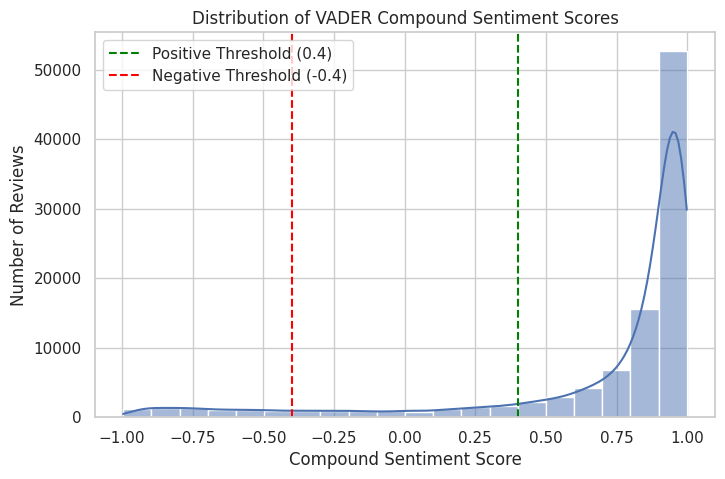

In [53]:
# Plot histogram of VADER compound scores to see the overall sentiment distribution in the working sample.
plt.figure(figsize=(8, 5))
sns.histplot(sentiments_df["sentiment_score"], bins=20, kde=True, color="#4C72B0")
plt.title("Distribution of VADER Compound Sentiment Scores")
plt.xlabel("Compound Sentiment Score")
plt.ylabel("Number of Reviews")
plt.axvline(0.4, color="green", linestyle="--", label="Positive Threshold (0.4)")
plt.axvline(-0.4, color="red", linestyle="--", label="Negative Threshold (-0.4)")
plt.legend()
plt.show()

To compare VADER labels with actual scores, we assign labels to them, with 3 being a neutral review, everything above being positive and everything below being negative.

In [54]:
# Map the original star rating to a sentiment label for comparison with VADER

def score_to_sentiment(score):
    """Map the original star rating to a sentiment label.
    Common thresholds:
      Score >= 4  -> positive
      Score <= 2  -> negative
      otherwise   -> neutral
    """
    if score >= 4:
        return "positive"
    elif score <= 2:
        return "negative"
    else:
        return "neutral"

In [55]:
# Add a column with the ground truth sentiment based on the original star rating

sentiments_df["ground_truth"] = sentiments_df["score"].apply(score_to_sentiment)
sentiments_df.head()

,id,score,sentiment_score,sentiment_label,ground_truth
0,0,5,0.9490,positive,positive
1,1,5,0.8720,positive,positive
2,2,4,0.9480,positive,positive
3,3,5,0.9423,positive,positive
4,4,5,0.9446,positive,positive


#### 6.4.1 Export results to CSV

To make comparison easier, like in Part A, the results are exported to a CSV. Original text is ommited, as it is not necessary for comparison.

In [56]:
import csv

# Write the Excel-friendly CSV next to the notebook.
OUTPUT_CSV = "sentiment_analysis_results.csv"

sentiments_df.to_csv(
    OUTPUT_CSV,
    index=False,
    encoding="utf-8-sig",   # makes Excel render accents/special chars correctly
    quoting=csv.QUOTE_ALL,  # wrap every field so commas/newlines stay inside cells
    lineterminator="\n",
)

print(f"Saved {len(sentiments_df)} rows to '{OUTPUT_CSV}'.")
print("Open it in Excel: columns are id | score | sentiment_score | sentiment_label | ground_truth for easy comparison.")

Saved 100000 rows to 'sentiment_analysis_results.csv'.
Open it in Excel: columns are id | score | sentiment_score | sentiment_label | ground_truth for easy comparison.


#### 6.5 Evaluation metrics

We compare the results of the VADER sentiment analysis with the labels assigned to actual scores using standard evaluation metrics like accuracy, F1 score and visualizing the results with a confusion matrix.

In [57]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Calculate accuracy and F1 score
accuracy = accuracy_score(sentiments_df["ground_truth"], sentiments_df["sentiment_label"])
f1 = f1_score(sentiments_df["ground_truth"], sentiments_df["sentiment_label"], average="weighted")
print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")

Accuracy: 0.7570
Weighted F1 Score: 0.7343


On first glance the accuracy seems satisfactory.

In [58]:
# Classification report (precision, recall, F1 per class)
report = classification_report(sentiments_df["ground_truth"], sentiments_df["sentiment_label"])
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

    negative       0.65      0.28      0.39     16105
     neutral       0.16      0.16      0.16      8709
    positive       0.83      0.93      0.88     75186

    accuracy                           0.76    100000
   macro avg       0.54      0.45      0.47    100000
weighted avg       0.74      0.76      0.73    100000



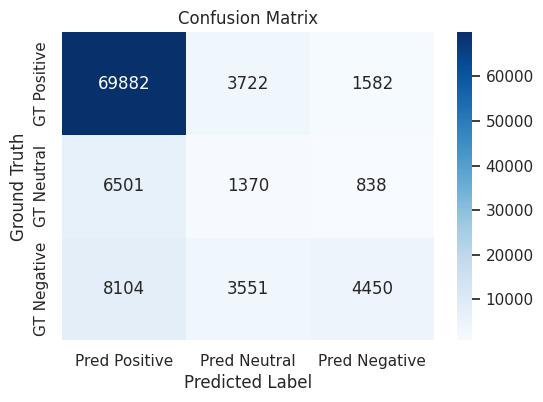

In [59]:
# Generate confusion matrix
cm = confusion_matrix(sentiments_df["ground_truth"], sentiments_df["sentiment_label"], labels=["positive", "neutral", "negative"])
cm_df = pd.DataFrame(cm, index=["GT Positive", "GT Neutral", "GT Negative"], columns=["Pred Positive", "Pred Neutral", "Pred Negative"])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Ground Truth")
plt.xlabel("Predicted Label")
plt.show()

Looking into the classification report and confusion matrix it can be seen that the relatively high accuracy is mostly driven by the positive class, with both negative and neutral classes being mislabelled much more frequently. This is the result of factors such as the small numbers of actual neutral and negative reviews, set standard VADER thresholds and values assigned to words inside the VADER lexicon.

---

## 7. Strengths and Weaknesses


### 7.1 Text Summarization (Flan-T5 XL)

**Strengths**

- **Abstractive & fluent:** Flan-T5 generates natural, grammatical sentences
  rather than copying fragments, so summaries read like human-written highlights.
- **Instruction-tuned & steerable:** because it follows natural-language prompts,
  we can control the summary (length, style, "one concise sentence") without
  retraining — and adapt it to the review domain instead of news.
- **Strong multi-task pre-training:** Flan-T5's instruction tuning across many
  tasks gives robust zero-shot generalization to product reviews.

**Weaknesses**

- **Hallucination:** like all abstractive models, it can invent details not
  present in the source (e.g. a brand name or a fact), which is dangerous for
  faithful review summarization.
- **Computational cost:** Flan-T5 XL has ~3B parameters; it really wants a GPU
  (in fp16 it needs ~6 GB VRAM), and on CPU summarizing many reviews is very
  slow.
- **Input-length limit:** the 512-token training context is *more* restrictive
  than BART's 1024, so very long reviews are truncated more aggressively.
- **Prompt sensitivity:** output quality depends on the wording of the prompt;
  a poorly phrased instruction can degrade the summary.

### 7.2 Keyword Extraction (KeyBERT)

**Strengths**

- **Semantic, not just frequency-based:** captures contextually relevant terms
  that TF-IDF would miss.
- **Flexible n-grams:** `ngram_range` lets us choose between single words and
  multi-word phrases; MMR controls diversity.
- **Lightweight default model:** `all-MiniLM-L6-v2` is fast and runs comfortably
  on CPU.

**Weaknesses**

- **No notion of importance beyond similarity:** a phrase can be central to the
  document embedding yet not be what a *human* would consider the key point.
- **Sensitive to preprocessing:** stop-word choice and casing affect results;
  noisy text can yield odd phrases.
- **Candidate generation cost:** for long documents with a wide n-gram range,
  the number of candidate phrases (and embeddings) grows quickly.
- **No built-in deduplication unless MMR is enabled** — without it, returned
  keyphrases can be near-duplicates ("great coffee", "coffee great").


### 7.3 Sentiment Analysis (VADER)

**Strengths**

- **Easy to set up and quick:** VADER requires no training data and using it
  doesn't require a lot of fine-tuning.Because it is a lexicon based model, it 
  produces results very quickly, doesn't require a GPU and can be used on large datasets
  efficiently.
- **Interpretable results:** the model provides results such as positive, negative,
  neutral and compound score, making it easy to understand why a given label was
  assigned, unlike many black-box models.
- **Designed for social media:** VADER was specifically designed for social media 
  text and using weights can interpret elements such as capitalization, 
  emojis, slang, abbreviations or punctuation.

**Weaknesses**

- **Weak handling of sarcasm and irony:** VADER handles some negation patterns and 
  intensifiers but may misclassify complex sarcasm or context-dependent irony.
- **Limited understanding of context and implicit sentiment:** VADER relies heavily 
  on sentiment-bearing words. It may miss subtle negativity and as a lexicon based model
  does not have true understanding of context.

---

## 8. Good Practices & Insights

Practical lessons from implementing the Part-A methods:

1. **Filter by length before summarizing.** Removing <50-word reviews avoids
   "summaries longer than the source", and capping at 300 words keeps inputs
   within the model's token budget — this single preprocessing step improved both
   speed and output quality.
2. **Always set `truncation=True`** at tokenization. Forgetting it causes hard
   errors on long inputs; with it, the model degrades gracefully when a review
   exceeds the 512-token context.
3. **Craft the instruction prompt deliberately.** With an instruction-tuned model
   like Flan-T5, the prompt *is* the task spec — being explicit ("in one concise
   sentence") measurably tightens the summaries.
4. **Prefer deterministic decoding (`do_sample=False`)** for reproducible
   academic results — sampling makes qualitative comparisons unreliable.
5. **Use `(1, 2)` n-grams as a sensible default for KeyBERT** on reviews:
   bigrams capture aspect+opinion phrases ("great flavor") that single words
   cannot, at negligible extra cost.
6. **Turn on MMR (`use_mmr=True`) when you need diverse keywords.** Without it,
   the top-n list is often crowded with synonyms of the single dominant theme.
7. **Cache / load heavy models once.** Loading a 3B-parameter model and the
   `KeyBERT` model is expensive; create them in a dedicated cell and reuse the
   objects, rather than re-instantiating inside a loop.
8. **Load big models in fp16 on GPU.** `torch_dtype=torch.float16` roughly halves
   VRAM use and speeds up generation; keep fp32 as the CPU fallback. A simple
   `torch.cuda.is_available()` check selects the device automatically.
9. **Validate qualitatively, not just quantitatively.** ROUGE alone hides
   hallucinations; reading a handful of original-vs-summary pairs (as we do in
   §6.1) is essential to catch unfaithful outputs.


Practical lessons from implementing the Part-B methods:

1. **Again, filter by length before analysing sentiment.** VADER is designed for short,
   concise social media texts. It may struggle with long paragraphs and it works best
   on sentence-level analysis. Therefore keeping texts a few sentences long is
   an optimal solution.
2. **Don't clean up the text too much.** While some cleaning up might be necessary,
   the model relies on elements like punctuation, emojis or case-sensitivity
   to assign scores and change weights of particular words.
3. **Consider your domain and language.** VADER was designed for social media,
   informal texts such as tweets. It often contains explicit emotional language.
   Therefore for more formal or business texts it might be better to use a different 
   model. It is also based on the english language only, although there are
   experimental versions for other languages as well as video or image analysis.
4. **Tune the sentiment thresholds.** Depending on the dataset, it might be useful
   to use thresholds different from the standard ones. Look at the classification
   report, confusion matrix and experiment with different values.
5. **Use VADER as a baseline.** VADER is often a strong baseline because it is
   simple and explainable. However it doesn't capture nuance and context,
   so it might be used for comparison with other machine learning methods or
   more sophisticated models.

---

## 9. Conclusion

New possibilities that emerged with the transformer attention mechanism led to a fast development in NLP since 2017. These architecture has revolutionized machine learning and specially NLP as it requires to analyze chaotic human language. It is extensively used in businness in applications such as summary creation, keyword extraction or sentiment analysis. ALthough the transformers deliver better results, they require more expensive and better hardware (NVIDIA graphics card), are more time and energy demanding and are not deterministic which can create unexpected hallucinations. The more classical approach in the form of VADER creates a decent result when we take in mind resource requirements which that algorythm requires. In the field of NLP it is crucial to choose the right method for the application that is needed as we need to balance between low-resource intensive alternatives that provide mediocre results and State of the Art models that provide incredible results at the cost of high capital investment in hardware and high operating costs.

In the examples presented in this work we demonstrate that NLP solutions can have business apllications. Our examples demonstrate that e-commerce platforms can benefit from advance and simple NLP algorithms to better interpret the reviews of their clients. By using the summary algorythm workers do not have to read entire reviews to know the main intent of the reviwer. Furthermore keyword extraction can be helpful to tag opinions based on categories and sentiment analysis can provide additional product rankings beside the classic 1-5 star scale. 